# Mission 01: Decoding the Building DNA 
### *Data Cleansing & Preparation for BPS 2024 Operations*

---

## Mission Brief
Every dataset tells a story, but raw data is often filled with "noise"—missing entries, mysterious "Not Available" strings, and extreme outliers. To build a **Mastermind Model**, we first need to clean the building DNA.

### Table of Contents
1. **[Prerequisites](#step1)**: Loading tools and libraries.
2. **[Data Import](#step2)**: Gathering the raw evidence.
3. **[Initial Audit](#step3)**: Understanding the missingness and data types.
4. **[DNA Restoration](#step4)**: Fixing missing tokens, dates, and numeric types.
5. **[Feature Engineering](#step5)**: Aggregation of sparse fuels.
6. **[Anomaly Detection](#step6)**: Sanity checks and outlier handling.
7. **[Exploratory Data Analysis](#step7)**: Visualizing patterns and correlations.
8. **[Final Evidence Export](#step8)**: Saving the model-ready dataset.

---

## 1. Prerequisites <a name="step1"></a>
We load our toolkit: `pandas` for data manipulation, `matplotlib` and `seaborn` for visualization, and `Path` for clean file handling.

In [25]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

# Set visualization style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
np.random.seed(42)

## 2. Data Import <a name="step2"></a>
We load the raw evidence from the BPS 2024 dataset.

In [26]:
RAW_DATA_PATH = "../data/2024_final_data_set.xlsx"

if not Path(RAW_DATA_PATH).exists():
    print(f"Evidence missing at {RAW_DATA_PATH}!")
else:
    df_raw = pd.read_excel(RAW_DATA_PATH)
    df = df_raw.copy()
    print(f"Mission Data Loaded: {df.shape[0]} buildings found with {df.shape[1]} descriptors.")

Mission Data Loaded: 11857 buildings found with 58 descriptors.


## 3. Initial Audit <a name="step3"></a>
Before we clean, we must understand the state of the data. We check for data types and where the gaps are.

In [27]:
print("### Data Type Summary")
display(df.dtypes.value_counts())

# Calculate missingness
missing_rate = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print("\n### Top Missing Fields (%)")
display(missing_rate.head(10))

### Data Type Summary


object            52
int64              3
datetime64[ns]     2
float64            1
Name: count, dtype: int64


### Top Missing Fields (%)


Postal Code                                  0.04
Address                                      0.02
List of All Property Use Types (GFA) (m²)    0.02
Subsector                                    0.00
Property Name                                0.00
Organization                                 0.00
Portfolio Manager Property ID                0.00
Portfolio Manager Parent Property ID         0.00
Year                                         0.00
Primary Property Type - Self Selected        0.00
dtype: float64

## 4. DNA Restoration <a name="step4"></a>
Many fields contain "Not Available" as a string, which prevents numeric analysis. We convert these to true Null values and fix data types.

In [28]:
MISSING_TOKENS = ["Not Available", "N/A", "NA", "na", "n/a", ""]

obj_cols = df.select_dtypes(include=["object"]).columns
for c in obj_cols:
    df[c] = df[c].astype("string").str.strip()
    df[c] = df[c].replace(MISSING_TOKENS, pd.NA)

print("Converted 'Not Available' strings to true Null values.")

Converted 'Not Available' strings to true Null values.


### Fixing Numeric Types
We identify columns that should be numbers based on units like (GJ) or (m²).

In [29]:
def to_numeric_clean(s):
    s = s.astype("string").str.replace(",", "", regex=False).str.strip()
    return pd.to_numeric(s, errors="coerce")

numeric_keywords = ["(kWh)", "(GJ)", "(therms)", "(m²)", "(ekWh/sqft)", "EUI", "Emissions", "Average Flow", "Influent Flow"]
numeric_cols = [col for col in df.columns if any(k in col for k in numeric_keywords)]

# Exception: One column contains text details even with (m²) in label
if "List of All Property Use Types (GFA) (m²)" in numeric_cols:
    numeric_cols.remove("List of All Property Use Types (GFA) (m²)")

for col in numeric_cols:
    df[col] = to_numeric_clean(df[col])

print(f"Successfully restored {len(numeric_cols)} numeric columns.")

Successfully restored 32 numeric columns.


## 5. Feature Engineering <a name="step5"></a>
Many fuel types (Propane, Kerosene, Wood) are rarely used. We group them together to reduce noise.

In [30]:
FUEL_COLS = ["Fuel Oil #1 Use (GJ)", "Fuel Oil #2 Use (GJ)", "Fuel Oil #4 Use (GJ)", "Fuel Oil #5 & 6 Use (GJ)", "Diesel Use (GJ)", "Kerosene Use (GJ)", "Propane Use (GJ)", "Wood Use (GJ)"]
DISTRICT_COLS = ["District Steam Use (GJ)", "District Hot Water Use (GJ)", "District Chilled Water Use (GJ)"]

fuel_exist = [c for c in FUEL_COLS if c in df.columns]
district_exist = [c for c in DISTRICT_COLS if c in df.columns]

df["Other_Fuels_GJ"] = df[fuel_exist].sum(axis=1, skipna=True)
df["District_Energy_GJ"] = df[district_exist].sum(axis=1, skipna=True)

# Binary Flags
df["Has_NaturalGas"] = df["Natural Gas Use (GJ)"].notna().astype(int) if "Natural Gas Use (GJ)" in df.columns else 0
df["Has_Electricity"] = df["Electricity Use - Grid Purchase (GJ)"].notna().astype(int) if "Electricity Use - Grid Purchase (GJ)" in df.columns else 0

print("Engineered aggregate energy features and binary indicators.")

Engineered aggregate energy features and binary indicators.


## 6. Anomaly Detection & Sanity Checks <a name="step6"></a>
We must ensure the data makes physical sense. Buildings with 0 area or missing emission targets are removed.

In [31]:
TARGET = "Total (Location-Based) GHG Emissions (Metric Tons CO2e)"
AREA = "Property GFA - Self-Reported (m²)"

before_n = df.shape[0]
df = df.dropna(subset=[TARGET]).copy()
df = df[df[AREA].fillna(0) > 0].copy()

print(f"Physicality Check: Kept {df.shape[0]} valid buildings (Removed {before_n - df.shape[0]} incomplete rows).")

Physicality Check: Kept 10291 valid buildings (Removed 1566 incomplete rows).


### Outlier Strategy
The 99.9th percentile is used to cap extreme emissions that likely represent data entry errors or unique industrial exceptions.

In [32]:
cap = df[TARGET].quantile(0.999)
df_final = df[df[TARGET] <= cap].copy()

print(f"Outlier Cap: Set at {cap:.2f} MT CO2e. Training on clean sample of {df_final.shape[0]} buildings.")

Outlier Cap: Set at 25713.51 MT CO2e. Training on clean sample of 10280 buildings.


## 7. Exploratory Data Analysis <a name="step7"></a>
We visualize the distribution of emissions and understand the impact across different sectors.

### 7.1. Distribution of Total GHG Emissions
We visualize the distribution of Greenhouse Gas emissions to understand its spread and identify potential skewness.


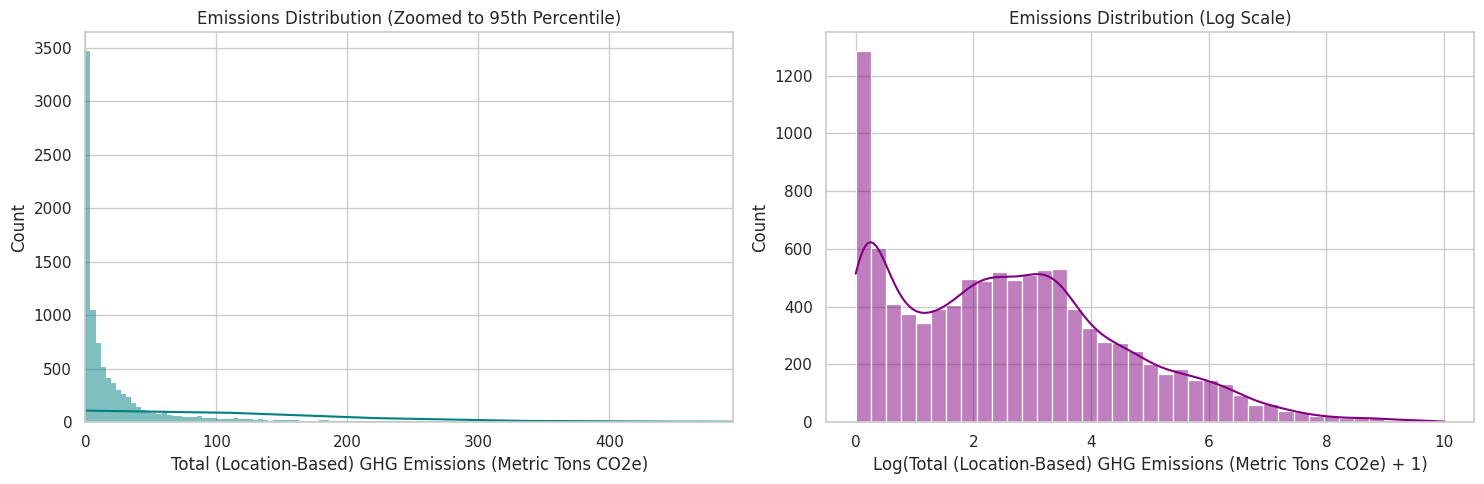

In [33]:
import numpy as np
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Zoomed version (excluding top 1% extreme outliers for visualization)
sns.histplot(df_final[TARGET], kde=True, color='teal', ax=ax1)
ax1.set_xlim(0, df_final[TARGET].quantile(0.95))
ax1.set_title('Emissions Distribution (Zoomed to 95th Percentile)')

# Log-scale version
sns.histplot(np.log1p(df_final[TARGET]), kde=True, color='purple', ax=ax2)
ax2.set_title('Emissions Distribution (Log Scale)')
ax2.set_xlabel(f'Log({TARGET} + 1)')

plt.tight_layout()
plt.show()

### 7.2. Total GHG Emissions by Sector
Exploring how emissions are distributed across different property sectors helps identify main contributors.


/tmp/ipykernel_211896/1542075946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='Sector', x=TARGET, data=df_final, palette='viridis')


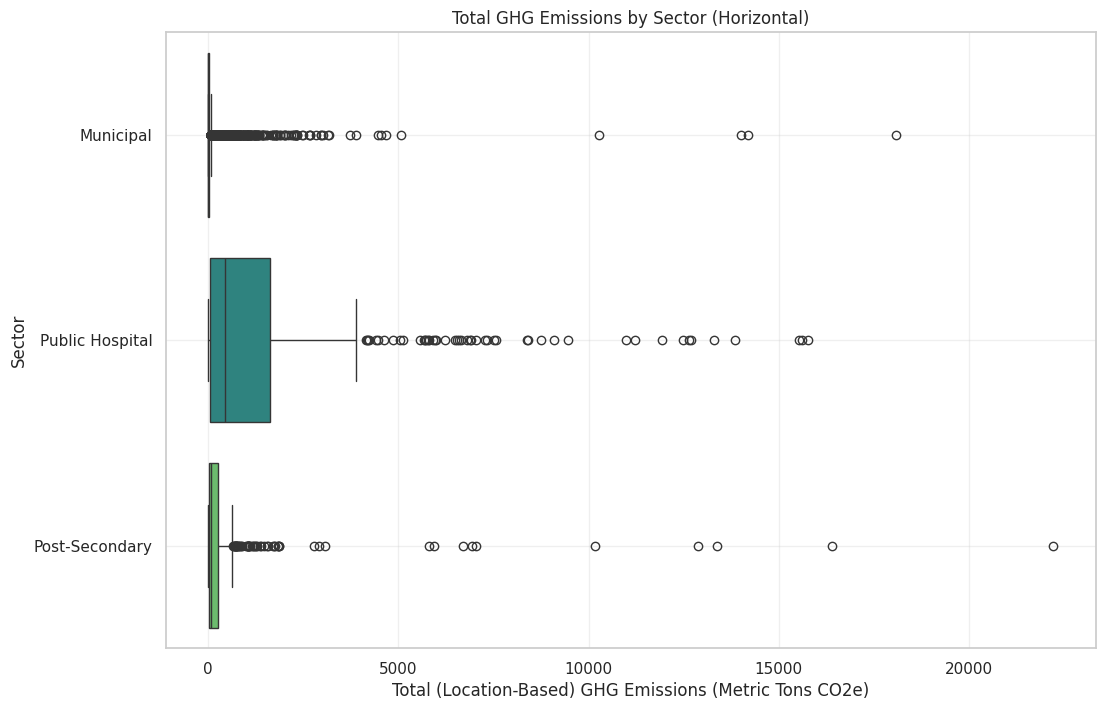

In [34]:
plt.figure(figsize=(12, 8))
sns.boxplot(y='Sector', x=TARGET, data=df_final, palette='viridis')
plt.title('Total GHG Emissions by Sector (Horizontal)')
plt.grid(True, alpha=0.3)
plt.show()


### 7.3. Correlation Heatmap
A correlation heatmap allows us to see the linear relationships between all numerical features.


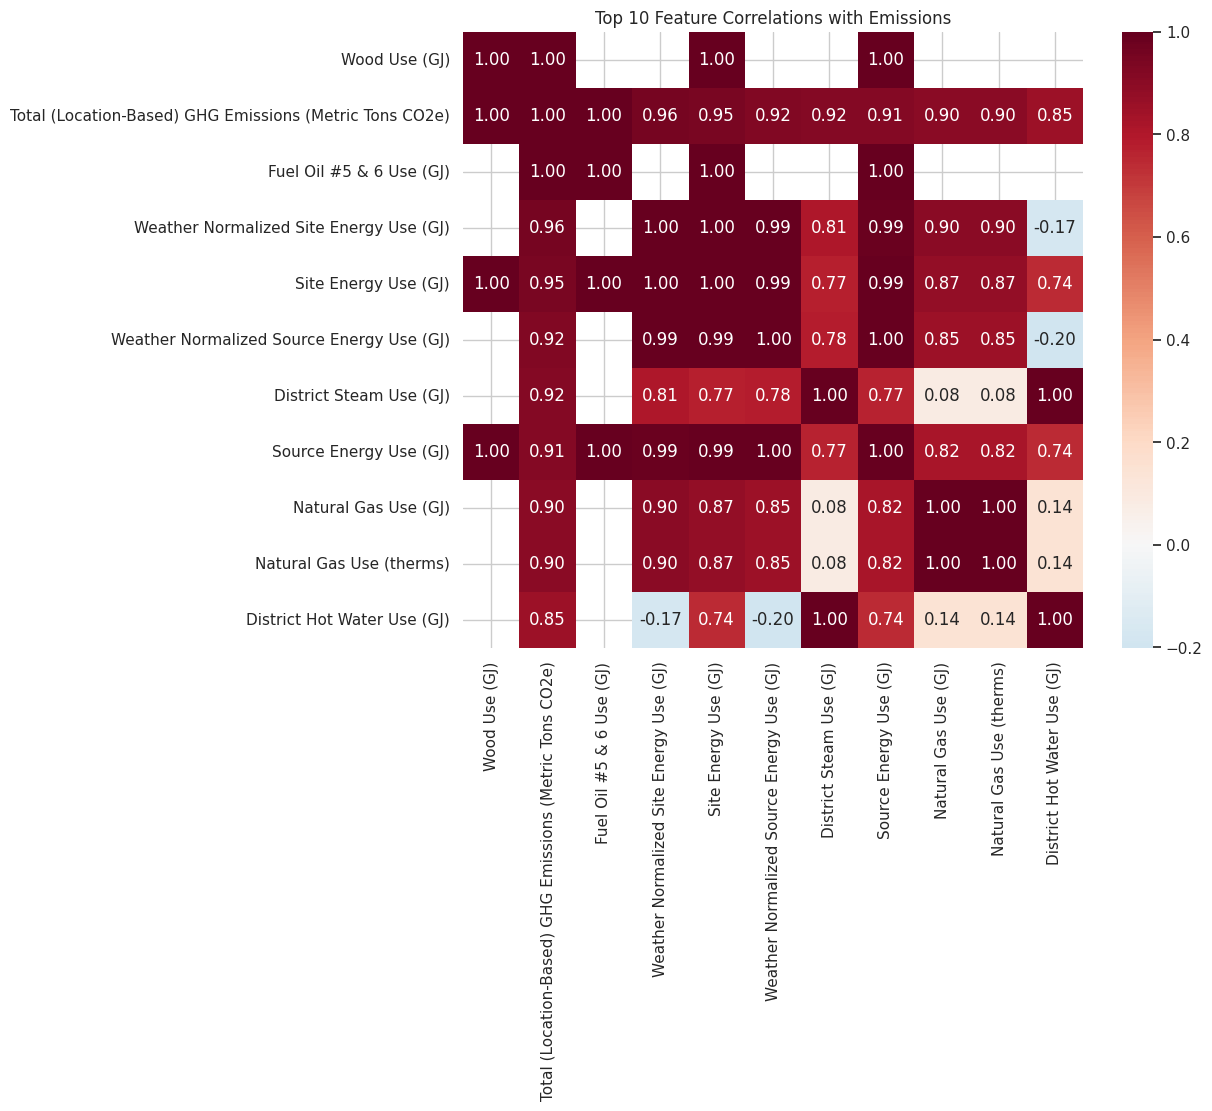

In [35]:
plt.figure(figsize=(10, 8))
# Filter for top 10 features most correlated with target
top_corr = df_final.select_dtypes(include=[np.number]).corr()[TARGET].abs().sort_values(ascending=False).head(11).index
sns.heatmap(df_final[top_corr].corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Top 10 Feature Correlations with Emissions')
plt.show()

### 7.4. Building Size vs. Total GHG Emissions
Investigating if larger buildings necessarily produce more emissions.


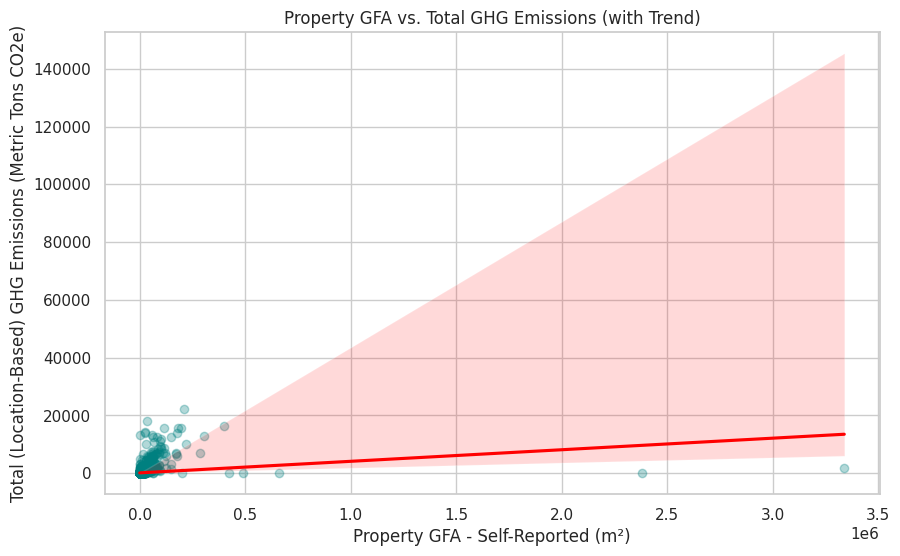

In [36]:
plt.figure(figsize=(10, 6))
sns.regplot(x=AREA, y=TARGET, data=df_final, 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
plt.title('Property GFA vs. Total GHG Emissions (with Trend)')
plt.show()


### 7.5. Natural Gas Use vs. Total GHG Emissions
Analyzing the impact of natural gas consumption on the overall carbon footprint.


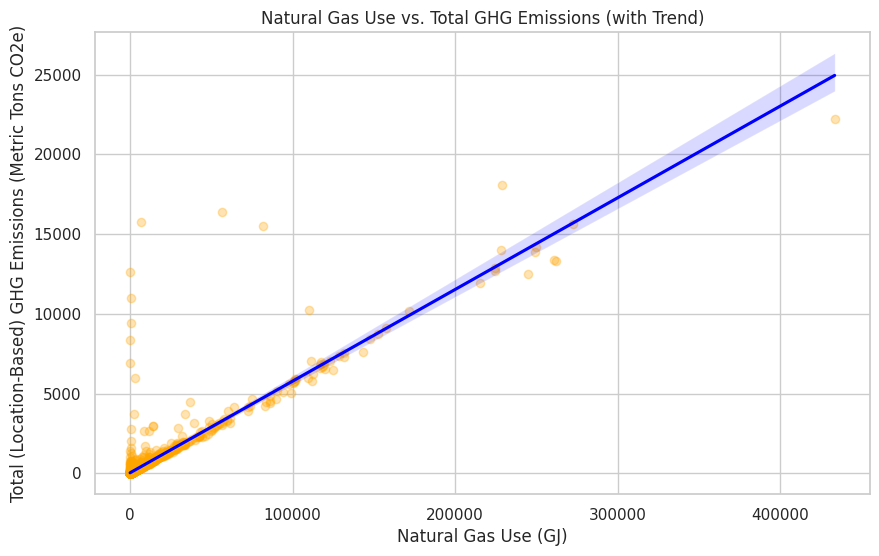

In [37]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Natural Gas Use (GJ)', y=TARGET, data=df_final, 
            scatter_kws={'alpha':0.3, 'color':'orange'}, line_kws={'color':'blue'})
plt.title('Natural Gas Use vs. Total GHG Emissions (with Trend)')
plt.show()


### 7.6. Building Size vs. Natural Gas Use
Understanding the relationship between building area and natural gas energy usage.


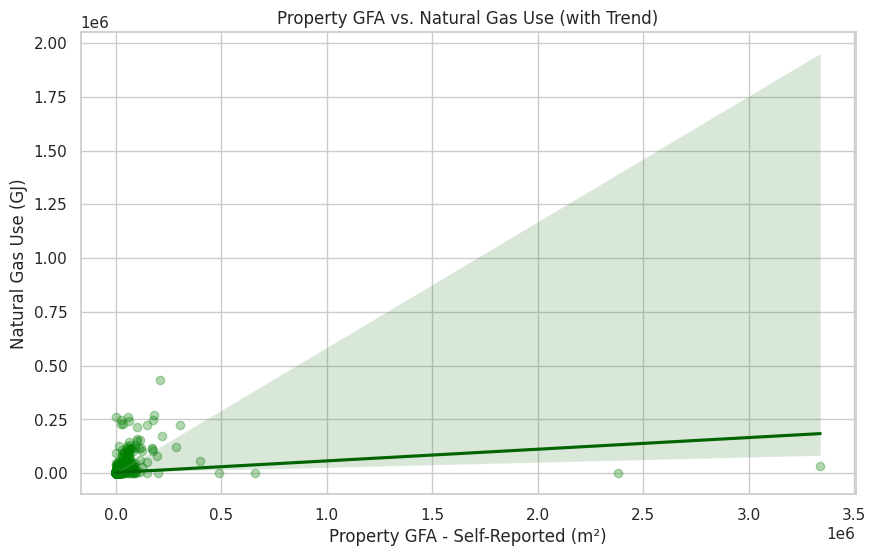

In [38]:
plt.figure(figsize=(10, 6))
sns.regplot(x=AREA, y='Natural Gas Use (GJ)', data=df_final, 
            scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'darkgreen'})
plt.title('Property GFA vs. Natural Gas Use (with Trend)')
plt.show()


## 8. Final Evidence Export <a name="step8"></a>
We save the evidence for the next stage of the mission: **Model Training.**

In [39]:
model_cols = [
    "Sector","Subsector","Primary Property Type - Self Selected","Largest Property Use Type",
    AREA,"Number of Buildings",
    "Electricity Use - Grid Purchase (GJ)","Natural Gas Use (GJ)",
    "Other_Fuels_GJ","District_Energy_GJ","Has_NaturalGas","Has_Electricity",
    TARGET
]

model_cols = [c for c in model_cols if c in df_final.columns]
df_model_ready = df_final[model_cols].copy()

OUTPUT_PATH = "../data/bps_2024_model_ready2.csv"
df_model_ready.to_csv(OUTPUT_PATH, index=False)

print(f"MISSION ACCOMPLISHED: Clean dataset saved to {OUTPUT_PATH}")

MISSION ACCOMPLISHED: Clean dataset saved to ../data/bps_2024_model_ready2.csv
